# Customer Personality Analysis
### Tools: Python, Pandas, Matplotlib, Seaborn
### Dataset: 2,240 customers | 29 columns
A marketing analysis project exploring customer spending behavior, 
demographics, and personality traits to identify key segments 
for targeted marketing strategies.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Ready to visualize! 🔥")
mk_camp = pd.read_csv('marketing_campaign.csv.xls',sep= '\t',index_col=False)
print(mk_camp.head(10))
mk_camp.info()
mk_camp.describe()

Ready to visualize! 🔥
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   
5  7446        1967      Master       Together  62513.0        0         1   
6   965        1971  Graduation       Divorced  55635.0        0         1   
7  6177        1985         PhD        Married  33454.0        1         0   
8  4855        1974         PhD       Together  30351.0        1         0   
9  5899        1950         PhD       Together   5648.0        1         1   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...        

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [25]:
mk_camp.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

## Data Cleaning

**Missing values:** 24 NaN values found in the `Income` column (0.7% of dataset).  
**Decision:** Filled with column mean to preserve remaining row data 
while minimizing impact on overall distribution.  
Dropping rows would have lost useful data from other columns 
(spending habits, age, family size) just because one field was missing.

**Outlier found:** Customer ID 2233 has an income of $666,666 — 
suspiciously round and 4x higher than the next highest value ($162,397).  
Flagged as likely data entry error. Kept in dataset but noted for exclusion 
in income-sensitive analysis.

**Dirty data:** Marital Status column contained invalid entries 
(`"Absurd"`, `"YOLO"`, `"Alone"`).  
Replaced `"Absurd"` and `"YOLO"` with `"Unknown"` and merged `"Alone"` into `"Single"`.

In [26]:
# Q1:Clean the data
mk_camp.isnull().sum()
# mk_camp['Income'].mean().round(2) <<< np.float64(52247.25)
# mk_camp[pd.isnull(mk_camp['Income'])]  #NaN for 24 click to see
mk_camp['Income'] = mk_camp['Income'].fillna(mk_camp['Income'].mean())

In [27]:
mk_camp['Marital_Status'].value_counts()
mk_camp['Marital_Status'] = mk_camp['Marital_Status'].replace({'Absurd' : 'Unknown','YOLO':'Unknown','Alone':'Single'})

## Income by Education Level

Higher education directly correlates with higher income.  
PhD and Master holders earn significantly more than Basic education customers.

**Why are PhD/Master holders older on average?**  
Advanced degrees take longer to complete, so holders are naturally older. 
There is also a generational factor — older generations who pursued PhDs 
despite it being less common tend to be specifically high achievers.

In [28]:
# Q2: What is the average income by education level?
average_income_byEd = mk_camp.groupby('Education')['Income'].mean().sort_values(ascending=False)
print(average_income_byEd)

Education
PhD           56105.210405
Master        52908.476370
Graduation    52715.755781
2n Cycle      47701.378099
Basic         20306.259259
Name: Income, dtype: float64


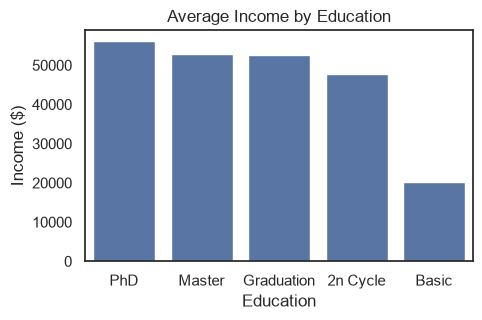

In [29]:
sns.set_theme(style='white')
plt.figure(figsize=(5, 3))
sns.barplot(x=average_income_byEd.index, y=average_income_byEd.values,order=average_income_byEd.index)
plt.title('Average Income by Education')
plt.xlabel('Education')
plt.ylabel('Income ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [30]:
# Q3: Which marital status group spends the most on wine
mk_camp['Marital_Status'].value_counts()
wine_by_mt = mk_camp.groupby('Marital_Status')['MntWines'].sum().sort_values(ascending=False)
print(wine_by_mt)
print(wine_by_mt.idxmax(), 'is the marital status group spends the most on wine')

Marital_Status
Married     258751
Together    177959
Single      138953
Divorced     75364
Widow        28434
Unknown       1355
Name: MntWines, dtype: int64
Married is the marital status group spends the most on wine


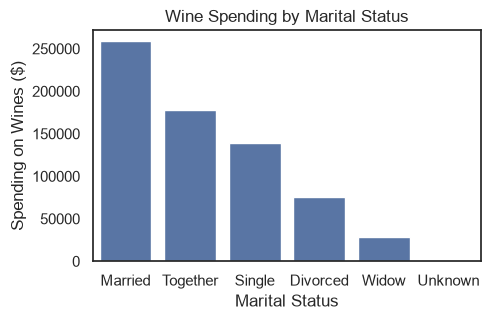

In [31]:
sns.set_theme(style='white')
plt.figure(figsize=(5, 3))
sns.barplot(x= wine_by_mt.index, y= wine_by_mt.values,order= wine_by_mt.index)
plt.title('Wine Spending by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Spending on Wines ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [32]:
# Q4:Create a new column Total_Spending
mk_camp['Total_Spending'] = (mk_camp['MntWines']+ mk_camp['MntFruits']+mk_camp['MntMeatProducts']
                            + mk_camp['MntFishProducts']+mk_camp['MntSweetProducts']+mk_camp['MntGoldProds'])
print(mk_camp['Total_Spending'])

0       1617
1         27
2        776
3         53
4        422
        ... 
2235    1341
2236     444
2237    1241
2238     843
2239     172
Name: Total_Spending, Length: 2240, dtype: int64


In [33]:
#Q5: Who are the top 10 highest spending customers? Return just their ID and Total_Spending, sorted highest to lowest
top_spender = mk_camp[['ID', 'Total_Spending']].sort_values('Total_Spending', ascending=False).head(10)
top_spender.head(10)

,ID,Total_Spending
1572,5350,2525
1179,5735,2525
1492,1763,2524
987,4580,2486
1052,4475,2440
1601,5453,2352
1458,10133,2349
1288,9010,2346
943,5386,2302
1301,6024,2302


In [34]:
# Q6: Create a new column "Age" based on the "Year_Birth" column. Assume the current year is 2024. 
# Then find the average age per education level.
mk_camp['Age'] = 2024 - mk_camp['Year_Birth']
mk_camp['Age']
avg_age_byed = mk_camp.groupby('Education')['Age'].mean().sort_values(ascending=False)
print(round(avg_age_byed,1))

Education
PhD           58.0
Master        57.1
Graduation    54.4
2n Cycle      52.0
Basic         46.5
Name: Age, dtype: float64


## Impact of Children on Spending

Customers without children spend nearly **3x more** than customers with children.  
($1,106 vs $406 average total spending)

**Insight:** Customers with children likely prioritize spending on their kids 
rather than themselves — "Child First, Parents Later."

**Business Recommendation:** There is a significant untapped opportunity 
in family-oriented product lines targeting customers with children. 
A "For Your Child" product category could capture currently redirected spending.

In [35]:
# Q7 — Create a new column "Has_Children" that is 1 if the customer has any children at home (Kidhome + Teenhome > 0), and 0 if not. 
# Then compare the average Total_Spending between customers with and without children.
mk_camp['Total_Children'] = mk_camp['Kidhome']+mk_camp['Teenhome']
# mk_camp['Total_Children'] #CHECKING Point

def fam_kid(total_children):
    if total_children > 0:
        return 1
    else: return 0

mk_camp['Has_children'] = mk_camp['Total_Children'].map(fam_kid)
# mk_camp['Has_children'] #CHECKING Point

# mk_camp['Has_Children'] = (mk_camp['Total_Children'] > 0).astype(int) 
# : RUN THIS CODE IS THE SAME PROCESS AS THE UPPER CODE
Spend_by_child = mk_camp.groupby('Has_children')['Total_Spending'].mean().round(2)
print(Spend_by_child)

Has_children
0    1106.03
1     406.58
Name: Total_Spending, dtype: float64


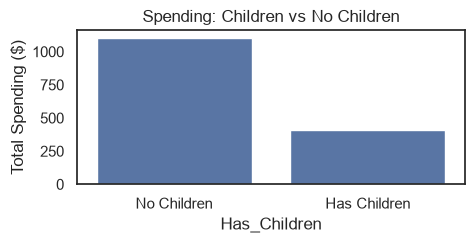

In [36]:
sns.set_theme(style='white')
plt.figure(figsize=(5, 2))
sns.barplot(x= Spend_by_child.index, y= Spend_by_child.values)
plt.title('Spending: Children vs No Children')
plt.xlabel('Has_Children')
plt.ylabel('Total Spending ($)')
plt.xticks([0, 1], ['No Children', 'Has Children']) #plt.xticks([positions], ['labels'])
plt.show()

## Income vs Total Spending Correlation

Moderate positive correlation found between Income and Total Spending.  
As income increases, spending tends to increase — but not perfectly.  
Other factors (family size, education, marital status) also influence spending behavior.

The scatter plot clearly shows the upward trend, and the outlier customer 
(income $666,666) is visually isolated far to the right.

In [37]:
# Q8 : Find the correlation between Income and Total_Spending. 
# Is it strong or weak? What does that tell you about this dataset? 
# (Hint: look up df["col"].corr() — new function, one liner)

# Why am i writing these two lines?
income_vs_spending = mk_camp[['Income', 'Total_Spending']].sort_values(by ='Total_Spending',ascending=False)
print(income_vs_spending)
# income_vs_spending.describe()

mk_camp['Income'].corr(mk_camp['Total_Spending'])

# THIS IS HOW CORREALTION WORKS
# >>>
# # Positive → A and B move together — when Income goes up, Spending tends to go up too ↑↑
# # Negative → A and B move opposite — when one goes up, the other goes down ↑↓
# <<<

        Income  Total_Spending
1572   90638.0            2525
1179   90638.0            2525
1492   87679.0            2524
987    75759.0            2486
1052   69098.0            2440
...        ...             ...
2132  156924.0               8
2129   33590.0               8
981     4861.0               6
655   153924.0               6
1524    3502.0               5

[2240 rows x 2 columns]


np.float64(0.6647064975273328)

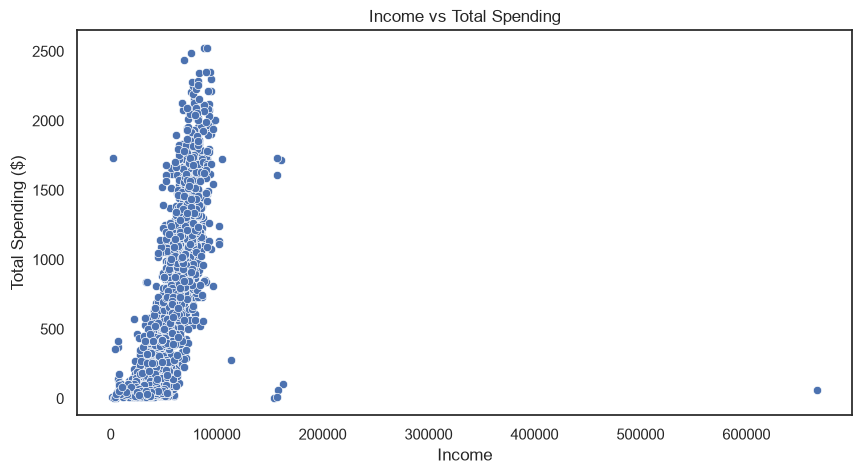

In [38]:
sns.set_theme(style='white')
plt.figure(figsize=(10, 5))
sns.scatterplot(data = mk_camp,x='Income',y='Total_Spending')
plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending ($)')
plt.show()

In [39]:
# Q9 — Identify any outliers in Income — customers whose income is more than 3 standard deviations away from the mean. 
# How many are there, and what are their income values? (Hint: you'll need .std() and .mean() together)

mk_camp['Income'].describe()
# STD tells you how much your data values deviate or spread out from the average

std_income = mk_camp['Income'].std()
mean_income = mk_camp['Income'].mean()
criteria = 3* std_income

lower_bound = mean_income - criteria
upper_bound = mean_income + criteria

outliers = mk_camp[(mk_camp['Income'] < lower_bound) | (mk_camp['Income'] > upper_bound)]
print(outliers['Income'].sort_values(ascending=False))


2233    666666.0
617     162397.0
687     160803.0
1300    157733.0
164     157243.0
1653    157146.0
2132    156924.0
655     153924.0
Name: Income, dtype: float64


In [40]:
# Q10: Which combination of Education + Marital Status has the highest average Total_Spending? 
# (Hint: you can pass a list of columns to groupby)
EDMS_by_topspd = mk_camp.groupby(['Education','Marital_Status'])['Total_Spending'].mean().sort_values(ascending=False).reset_index()
print(EDMS_by_topspd)

     Education Marital_Status  Total_Spending
0   Graduation        Unknown     1216.000000
1       Master        Unknown     1169.000000
2       Master          Widow      879.750000
3          PhD          Widow      797.666667
4       Master         Single      744.539474
5          PhD        Married      715.828125
6     2n Cycle          Widow      677.200000
7   Graduation          Widow      677.142857
8   Graduation       Together      658.979021
9     2n Cycle       Divorced      651.173913
10         PhD       Together      649.564103
11         PhD       Divorced      632.865385
12  Graduation       Divorced      616.411765
13         PhD         Single      610.626263
14  Graduation         Single      608.138340
15  Graduation        Married      595.912240
16      Master        Married      566.666667
17      Master       Together      560.849057
18      Master       Divorced      551.297297
19    2n Cycle         Single      539.108108
20    2n Cycle       Together     

In [41]:
mk_camp['Marital_Status'].value_counts()
mk_camp['Marital_Status'] = mk_camp['Marital_Status'].replace({'Absurd' : 'Unknown','YOLO':'Unknown','Alone':'Single'})

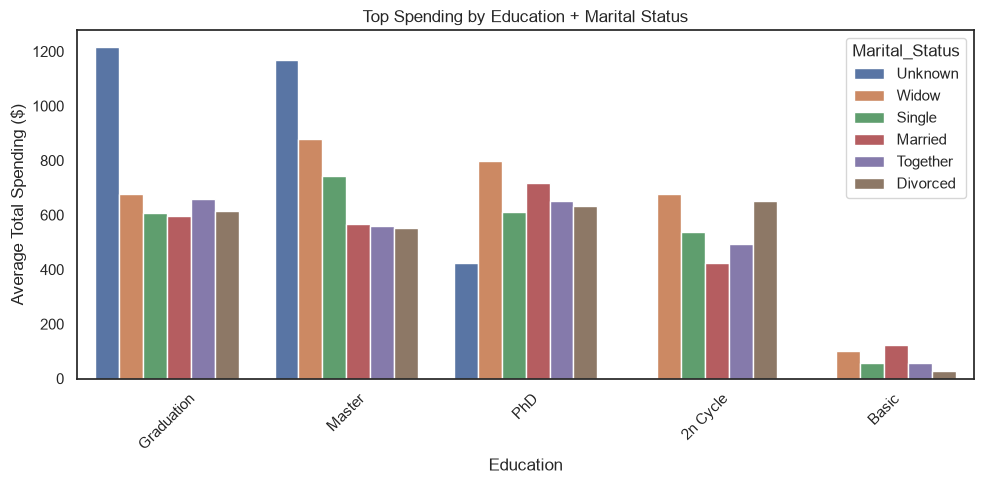

In [42]:
sns.set_theme(style='white')
plt.figure(figsize=(10, 5))
sns.barplot(data=EDMS_by_topspd, x='Education', y='Total_Spending', hue='Marital_Status')
plt.title('Top Spending by Education + Marital Status')
plt.xlabel('Education')
plt.ylabel('Average Total Spending ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Business Recommendations

Based on the full analysis, three customer segments stand out:

1. **High-value targets:** Educated (Master/PhD), higher income, 
   no children at home — especially Widows who spend the most across all groups.
   → Target with premium product offerings.

2. **Untapped family segment:** Customers with children spend significantly less 
   on personal products.  
   → Develop child-oriented product lines to capture redirected spending.

3. **Low-engagement segment:** Basic education customers spend the least 
   across ALL marital statuses.  
   → Either deprioritize or target with budget-friendly entry-level products.